In [16]:
import pandas as pd
import numpy as np


In [17]:
city = '北京'

In [18]:
housing = pd.read_csv(f'processed_data/{city}/04_data.csv')

In [19]:
housing.columns

Index(['城市', '区域', '板块', 'price', 'unit_price', '配备电梯', '挂牌时间', '上次交易', '产权所属',
       '核心卖点',
       ...
       '房源标签_is_房本满五年', '房源标签_is_VR房源', '房源标签_is_地铁', '房源标签_is_随时看房',
       '房源标签_is_房本满两年', 'category_is_Others', 'category_is_High-Tech',
       'category_is_General-Mfg', 'category_is_Heavy-Nuisance',
       'category_is_Modern-Service'],
      dtype='object', length=106)

In [20]:
stats = housing.drop(columns=['城市', '区域', '板块', '挂牌时间', '上次交易', '核心卖点', '户型介绍', '周边配套', '交通出行'
                              ,'nearest_park_index','nearest_park_industry','x','y'])

In [21]:
from utils import Display

Display(stats)

Shape: (261159, 93)
Index(['price', 'unit_price', '配备电梯', '产权所属', '年份', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center',
       'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交

,Missing,Unique,Dtype
price,0,2818,float64
unit_price,0,99366,float64
配备电梯,0,2,int64
产权所属,0,2,int64
年份,1193,8,float64
...,...,...,...
category_is_Others,0,2,int64
category_is_High-Tech,0,2,int64
category_is_General-Mfg,0,2,int64
category_is_Heavy-Nuisance,0,2,int64


【col: price】
  - 450.0: 1974 次
  - 550.0: 1686 次
  - 420.0: 1667 次
  - 320.0: 1663 次
  - 330.0: 1647 次
----------------------------------------
【col: unit_price】
  - 100000.0: 112 次
  - 50000.0: 43 次
  - 125000.0: 41 次
  - 45455.0: 39 次
  - 62500.0: 37 次
----------------------------------------
【col: 配备电梯】
  - 1: 148836 次
  - 0: 112323 次
----------------------------------------
【col: 产权所属】
  - 2: 228758 次
  - 1: 32401 次
----------------------------------------
【col: 年份】
  - 2023.0: 133246 次
  - 2022.0: 102997 次
  - 2021.0: 12168 次
  - 2024.0: 9499 次
  - 2020.0: 1364 次
----------------------------------------
【col: nearest_park_dist_km】
  - 1.0558044660826411: 531 次
  - 0.1682971198726757: 527 次
  - 0.2633951853487862: 523 次
  - 12.279585246760934: 517 次
  - 1.251156431953514: 494 次
----------------------------------------
【col: log_price】
  - 6.1092475827643655: 1974 次
  - 6.309918278226516: 1686 次
  - 6.040254711277414: 1667 次
  - 5.768320995793772: 1663 次
  - 5.799092654460526: 1647 

In [22]:
missing_cols = stats.isnull().sum()
print(missing_cols[missing_cols > 0])

stats = stats.dropna(subset=['年份'])

年份    1193
dtype: int64


In [23]:
stats.columns

Index(['price', 'unit_price', '配备电梯', '产权所属', '年份', 'nearest_park_dist_km',
       'log_price', 'log_unit_price', 'area', 'distance_to_center',
       'administrative_level', 'block', 'nearest_subway_dist_km', 'rooms',
       'halls', 'kitchens', 'bathrooms', '看房时间_is_只周末可看', '看房时间_is_下班后可看',
       '看房时间_is_提前预约随时可看', '看房时间_is_有租户需预约', 'total_floors',
       'floor_level_is_低楼层', 'floor_level_is_底层', 'floor_level_is_高楼层',
       'floor_level_is_中楼层', 'floor_level_is_顶层', 'floor_level_is_地下室',
       '房屋朝向_is_南', '房屋朝向_is_北', '房屋朝向_is_东', '房屋朝向_is_西', '房屋朝向_is_西北',
       '房屋朝向_is_西南', '房屋朝向_is_东南', '房屋朝向_is_东北', '建筑结构_is_钢混结构',
       '建筑结构_is_混合结构', '建筑结构_is_未知结构', '建筑结构_is_砖混结构', '建筑结构_is_钢结构',
       '建筑结构_is_砖木结构', '建筑结构_is_框架结构', '装修情况_is_精装', '装修情况_is_简装',
       '装修情况_is_毛坯', '装修情况_is_其它', '装修情况_is_其他', 'elevators', 'households',
       'elevators_household_ratio', '别墅类型_is_非别墅', '别墅类型_is_独栋', '别墅类型_is_联排',
       '别墅类型_is_叠拼', '别墅类型_is_双拼', '交易权属_is_私产', '交易权属_is_商品房', '交易权属_i

In [24]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 准备数据
# 复制一份数据，避免在原始 dataframe 上直接修改
X = stats.drop(columns=['log_price', 'price', 'log_unit_price', 'unit_price']).copy()
y = stats['log_unit_price']

# 2. 加入 nearest_park_dist_km 的二次项 (平方项)
# 这一步是为了捕捉公园距离与房价之间的非线性关系

# 3. 处理分类变量 (如果是统计回归，非数值列需要转为哑变量/One-hot)
# 检查 X 中是否存在非数值列，并进行转换
X = pd.get_dummies(X, drop_first=True) 

# 5. 添加截距项 (statsmodels 默认不包含截距，必须手动添加)
X_with_constant = sm.add_constant(X)

# 6. 构建并拟合 OLS 模型
# 使用 .astype(float) 确保所有数据为数值型，避免报错
model = sm.OLS(y, X_with_constant.astype(float))
results = model.fit()

# 7. 输出统计回归总结报告
print(results.summary())

# 如果你想提取系数表格到 DataFrame
coef_df = pd.DataFrame({
    'Feature': results.params.index,
    'Coefficient': results.params.values,
    'P-Value': results.pvalues.values,
    'Std.Err': results.bse.values
})
print("\n系数汇总表：")
print(coef_df)

                            OLS Regression Results                            
Dep. Variable:         log_unit_price   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                 2.205e+04
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:46:52   Log-Likelihood:                 57982.
No. Observations:              259966   AIC:                        -1.158e+05
Df Residuals:                  259885   BIC:                        -1.150e+05
Df Model:                          80                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 准备数据
# 复制一份数据，避免在原始 dataframe 上直接修改
X = stats.drop(columns=['log_price', 'price', 'log_unit_price', 'unit_price']).copy()
y = stats['log_unit_price']

# 2. 加入 nearest_park_dist_km 的二次项 (平方项)
# 这一步是为了捕捉公园距离与房价之间的非线性关系
X['nearest_park_dist_km_sq'] = X['nearest_park_dist_km'] ** 2

# 3. 处理分类变量 (如果是统计回归，非数值列需要转为哑变量/One-hot)
# 检查 X 中是否存在非数值列，并进行转换
X = pd.get_dummies(X, drop_first=True) 

# 5. 添加截距项 (statsmodels 默认不包含截距，必须手动添加)
X_with_constant = sm.add_constant(X)

# 6. 构建并拟合 OLS 模型
# 使用 .astype(float) 确保所有数据为数值型，避免报错
model = sm.OLS(y, X_with_constant.astype(float))
results = model.fit()

# 7. 输出统计回归总结报告
print(results.summary())

# 如果你想提取系数表格到 DataFrame
coef_df = pd.DataFrame({
    'Feature': results.params.index,
    'Coefficient': results.params.values,
    'P-Value': results.pvalues.values,
    'Std.Err': results.bse.values
})
print("\n系数汇总表：")
print(coef_df)

                            OLS Regression Results                            
Dep. Variable:         log_unit_price   R-squared:                       0.872
Model:                            OLS   Adj. R-squared:                  0.872
Method:                 Least Squares   F-statistic:                 2.191e+04
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        19:46:54   Log-Likelihood:                 58686.
No. Observations:              259966   AIC:                        -1.172e+05
Df Residuals:                  259884   BIC:                        -1.163e+05
Df Model:                          81                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [26]:
from my_xgboost import XGBGPUTrainer
from sklearn.model_selection import train_test_split

X = stats.drop(columns=['log_price','price','log_unit_price','unit_price'])
y = stats['log_unit_price']

np.expm1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

params = {
    'n_estimators': 5000,
    'learning_rate': 0.01,
    'max_depth': 9,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'tree_method': 'hist',
    'device': 'cuda',
    'early_stopping_rounds': 50
}
trainer = XGBGPUTrainer(params)
trainer.train(X_train, y_train, X_test, y_test)

metrics, final_preds = trainer.evaluate(X_test, y_test, inverse_func=np.expm1)

print(f"Test Metrics: {metrics}")

[0]	validation_0-rmse:10.31852	validation_1-rmse:10.31936
[100]	validation_0-rmse:3.78209	validation_1-rmse:3.78248
[200]	validation_0-rmse:1.39404	validation_1-rmse:1.39440
[300]	validation_0-rmse:0.52968	validation_1-rmse:0.53068
[400]	validation_0-rmse:0.23340	validation_1-rmse:0.23640
[500]	validation_0-rmse:0.14966	validation_1-rmse:0.15532
[600]	validation_0-rmse:0.13016	validation_1-rmse:0.13754
[700]	validation_0-rmse:0.12348	validation_1-rmse:0.13203
[800]	validation_0-rmse:0.11922	validation_1-rmse:0.12876
[900]	validation_0-rmse:0.11587	validation_1-rmse:0.12621
[1000]	validation_0-rmse:0.11279	validation_1-rmse:0.12387
[1100]	validation_0-rmse:0.11016	validation_1-rmse:0.12192
[1200]	validation_0-rmse:0.10762	validation_1-rmse:0.12000
[1300]	validation_0-rmse:0.10535	validation_1-rmse:0.11833
[1400]	validation_0-rmse:0.10327	validation_1-rmse:0.11682
[1500]	validation_0-rmse:0.10137	validation_1-rmse:0.11543
[1600]	validation_0-rmse:0.09949	validation_1-rmse:0.11407
[1700]	

In [27]:
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

y_pred = trainer.predict(X_test)

print("正在计算 SHAP 值...")

def model_predict(data):
    return trainer.model.predict(data)

masker = shap.maskers.Independent(data=X_train)
explainer = shap.Explainer(model_predict, masker)

X_test_sample = X_test.head(200) 
shap_values = explainer(X_test_sample)


正在计算 SHAP 值...


PermutationExplainer explainer: 201it [00:53,  2.99it/s]                         


/tmp/ipykernel_1660698/3607603651.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


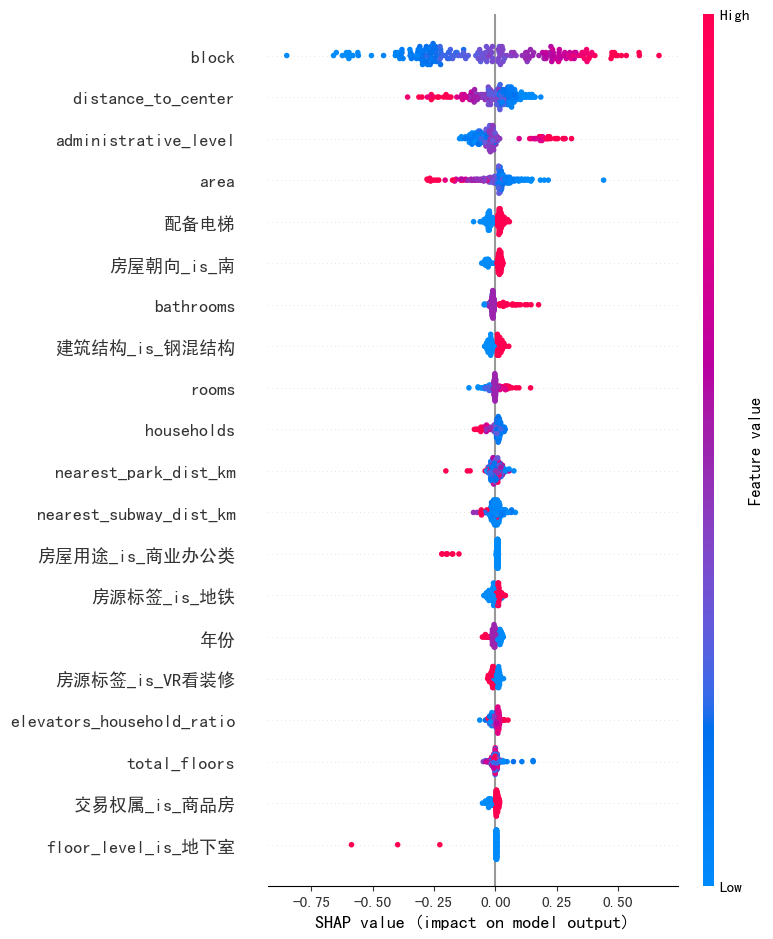

/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/home/yubo/.conda/envs/Housing/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


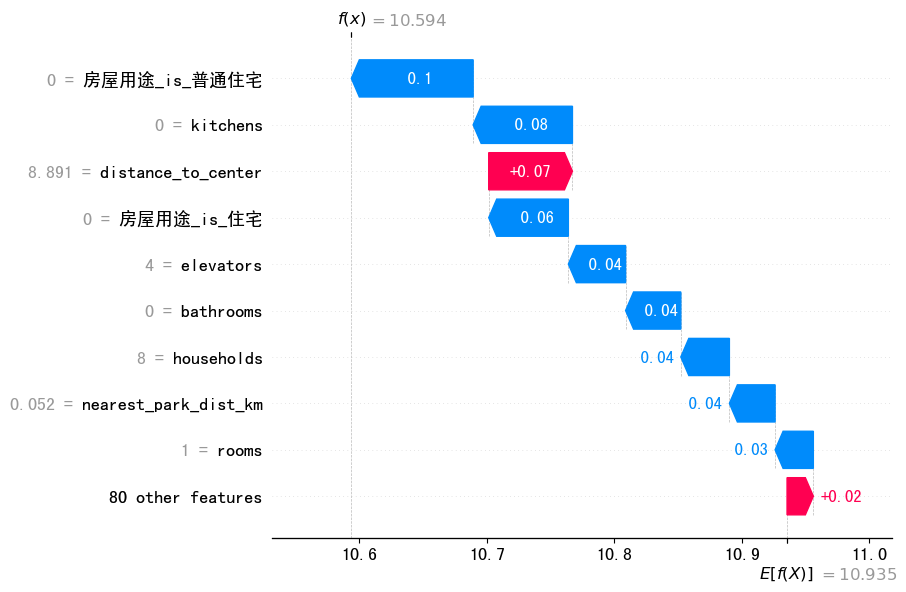

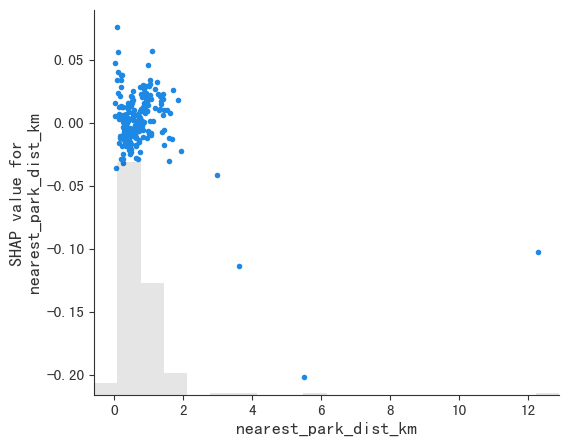

In [28]:
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample)
plt.show()

plt.figure(figsize=(12, 5))
shap.plots.waterfall(shap_values[0])
plt.show()

shap.plots.scatter(shap_values[:, "nearest_park_dist_km"])

正在生成 km 的 PDP 图...


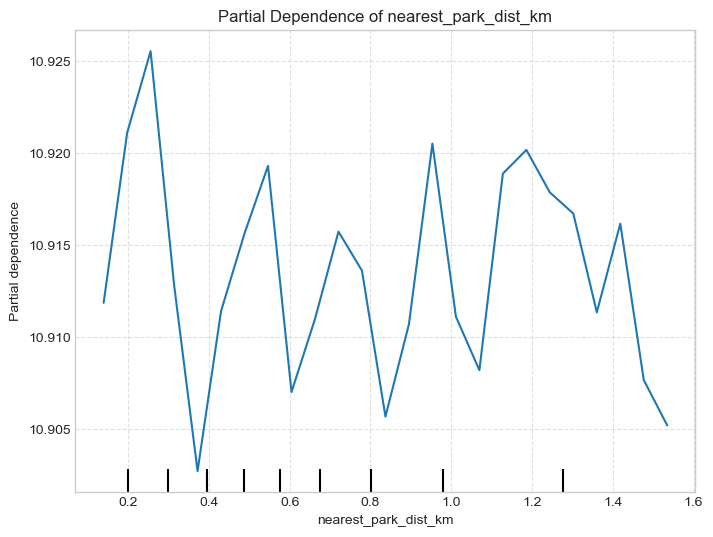

In [32]:
print("正在生成 km 的 PDP 图...")

fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    trainer.model, 
    X_train, 
    features=['nearest_park_dist_km'], 
    ax=ax,
    grid_resolution=25
)

plt.title("Partial Dependence of nearest_park_dist_km")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()